# New MeSH medical terms as a held-out check set: `data.py` demo

This notebook walks through **`data.py`**, the script that packages the *held-out MeSH confirmation population* into the pipeline's `exp_sel_data_out` schema (`full_data_out.json`).

**What the population is.** It holds 191 new biomedical concepts, each one a MeSH descriptor established between 2006 and 2016 (widened to 2004–2005 and 2017–2018). Each concept passed three filters:
1. a Nentidis-style provenance filter, which drops parenthetical-prior-year, promoted and renamed descriptors;
2. a PubMed `[tiab]` novelty pre-screen;
3. the main corpus's final emergence rule on OpenAlex counts: first year with ≥5 papers `F` in 2005–2016, 20–300 papers in `F..F+2`, and ≤8,000 papers in total over 2000–2024.

The population serves as an independent check set for the emerging-concept study ("occupancy is not integration"). Concept identity and synonyms come only from MeSH, not from the text-mining pipeline under test.

**What `data.py` does.** It reads two source tables and turns each row into one `{input, output, metadata_*}` example:

| dataset | 1 example per | `input` | `output` |
|---|---|---|---|
| `heldout_mesh_concepts` | concept | concept identity as JSON: descriptor UI, preferred term, surface forms, acronyms, tree numbers, `F`, origin field/subfield | yearly incidence 2000–2024 and retrieval counts as JSON |
| `mesh_synonym_pairs` | term pair | `{"term_a","term_b"}` | `"1"` for a synonym or acronym, `"0"` for a hard negative |

It also writes a small preview of the concept–work rows (`works/works_part_XX.jsonl.gz`).

**Demo data.** The full source tables are about 10 MB and are not needed here. `mini_demo_data.json` is a curated subset:
- **60 of the 191 concepts**, stratified by MeSH branch group and by final-rule basis;
- **40 held-out synonym or hard-negative pairs**, covering every pair type;
- **10 raw concept–work rows**.

The script's code is unchanged except where it reads these tables. There it takes them from the loaded `data` dict rather than from `temp/datasets/`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# data.py itself only uses the Python standard library (gzip, json, sys, pathlib).
# numpy, pandas, matplotlib are used for the summary/visualisation cells — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- original import block of data.py ---
from __future__ import annotations

import gzip
import json
import sys
from pathlib import Path

# --- additional imports for the notebook (summary + plots) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-1/dataset-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print({k: len(v) if isinstance(v, list) else len(v.get("pairs", v)) for k, v in data.items() if k != "metadata"})

Curated demo subset of the held-out MeSH confirmation population: the two source tables data.py reads from temp/datasets/ (60 of 191 concepts stratified by MeSH branch group and final-rule basis; 40 held-out synonym/hard-negative pairs across all pair types) plus 10 raw concept-work rows from works/works_part_XX.jsonl.gz.
{'heldout_mesh_concepts': 60, 'mesh_synonym_pairs': 40, 'works_rows': 10}


## Configuration

`data.py` has no numeric hyper-parameters. The only settings are how many rows it processes and how large the mini and preview files are. The values below cover the whole demo subset:
- 60 concepts
- 40 pairs
- 10 work rows

To see the original scale, run the script on the full source tables with `uv run data.py`. It then processes all 191 concepts and 23,097 pairs, which takes a few seconds.

In [5]:
N_CONCEPTS = 60        # concepts to package (demo subset has 60; original: all 191 rows of heldout_mesh_concepts.json)
N_PAIRS = 40           # synonym / hard-negative pairs to package (demo subset has 40; original: all 23,097 pairs)
N_WORKS_SAMPLE = 10    # concept-work rows sampled for preview_works.json (original: works_sample(10))
MINI_N = 3             # rows kept in mini_works.json (original: wex[:3])
TRUNCATE_N = 200       # max string length in preview_works.json (original: truncate(..., n=200))

## Paths and dataset list

In the original script, `ROOT` is the script's own directory and `SRC` is `ROOT/temp/datasets`. A notebook has no `__file__`, so `ROOT` is set to the current working directory here. Outputs such as `full_data_out.json` are written there. The source tables come from `data`, not `SRC`.

In [6]:
ROOT = Path.cwd()                     # original: Path(__file__).resolve().parent
SRC = ROOT / "temp" / "datasets"      # kept for reference; in the notebook the source tables come from `data`
DATASETS = ["heldout_mesh_concepts", "mesh_synonym_pairs"]

## Helpers: compact JSON and flat metadata

The `exp_sel_data_out` schema requires `input` and `output` to be **strings**, and metadata to be **flat** `metadata_*` fields. `dumps` serialises with compact separators. `flat_metadata` lifts one level of nesting, so that `{"pubmed_prescreen": {"F_pubmed": ...}}` becomes `metadata_pubmed_prescreen_F_pubmed`.

In [7]:
def dumps(o) -> str:
    return json.dumps(o, ensure_ascii=False, separators=(",", ":"))


def flat_metadata(meta: dict, prefix: str = "metadata_") -> dict:
    """Flatten one nesting level into metadata_<key> / metadata_<key>_<sub> fields (schema wants flat fields)."""
    out = {}
    for k, v in meta.items():
        if isinstance(v, dict):
            for k2, v2 in v.items():
                out[f"{prefix}{k}_{k2}"] = v2
        else:
            out[f"{prefix}{k}"] = v
    return out

## Dataset 1: `heldout_mesh_concepts` (one example per concept)

Each source row has three parts:

- **`input`**: the MeSH identity of the concept. This is the descriptor UI, the preferred term, `surface_forms` (the preferred-concept terms used for text matching), `excluded_forms` and `acronyms`, the tree numbers, `DateEstablished`, and the provenance class. It also includes the emergence year `F`, the count `early_count_F_to_F2`, and the OpenAlex `origin_field` and `origin_subfield`.
- **`output`**: the yearly incidence series for 2000–2024. It includes `yearly_counts_textmatch` (locally verified text matches), `yearly_counts_mesh_indexed`, `yearly_counts_nonpubmed_openalex_groupby` and `yearly_counts_final_rule`. It also records `final_rule_basis`, which says which retrieval route the final rule relied on, and the retrieval counts.
- **`metadata`**: the stratum, sample rank, seed, `retrieval_complete`, `rule_parity` and similar fields.

Each row becomes an example whose `input` and `output` are JSON strings. A few convenience metadata fields are added as well.

*Change from the original:* `rows` comes from `data["heldout_mesh_concepts"]` instead of `SRC/heldout_mesh_concepts.json`, and is truncated to `N_CONCEPTS`.

In [8]:
def concepts() -> list[dict]:
    rows = data["heldout_mesh_concepts"][:N_CONCEPTS]   # original: json.loads((SRC / "heldout_mesh_concepts.json").read_text())
    ex = []
    for i, c in enumerate(rows):
        e = {"input": dumps(c["input"]), "output": dumps(c["output"]), "metadata_fold": c["metadata_fold"]}
        e.update(flat_metadata(c["metadata"]))
        e.update({"metadata_row_index": i, "metadata_concept_id": c["input"]["concept_id"],
                  "metadata_preferred_term": c["input"]["preferred_term"], "metadata_F": c["input"]["F"],
                  "metadata_task_type": "emergence_trajectory",
                  "metadata_input_fields": sorted(c["input"]), "metadata_output_fields": sorted(c["output"])})
        ex.append(e)
    return ex

## Dataset 2: `mesh_synonym_pairs` (one example per term pair)

The pairs come from MeSH (desc2017) and cover all 3,430 provenance-filtered descriptors from 2006–2016.

- **Positives** (label `1`) are `synonym` and `acronym_expansion` pairs.
- **Hard negatives** (label `0`) come from a sibling descriptor, or from a narrower, broader or related non-preferred concept.

The `metadata_fold` field guards against leakage. It takes one of three values:
- `heldout_mesh`: the pair belongs to one of the 191 concepts;
- `working_list`: the pair belongs to the wider candidate list;
- `train_eligible`: the pair is safe to use for training a synonym or grounding model.

*Change from the original:* `d` comes from `data["mesh_synonym_pairs"]` instead of `SRC/mesh_synonym_pairs.json`. Its `pairs` list is truncated to `N_PAIRS`. The demo subset contains only held-out pairs.

In [9]:
def pairs() -> list[dict]:
    d = data["mesh_synonym_pairs"]   # original: json.loads((SRC / "mesh_synonym_pairs.json").read_text())
    ex = []
    for i, p in enumerate(d["pairs"][:N_PAIRS]):
        fold = "heldout_mesh" if p["in_heldout_population"] else ("working_list" if p["in_working_list"] else "train_eligible")
        ex.append({"input": dumps({"term_a": p["term_a"], "term_b": p["term_b"]}), "output": str(p["label"]),
                   "metadata_fold": fold, "metadata_pair_type": p["pair_type"],
                   "metadata_descriptor_ui": p["descriptor_ui"], "metadata_descriptor_ui_b": p["descriptor_ui_b"],
                   "metadata_orig_a": p["orig_a"], "metadata_orig_b": p["orig_b"],
                   "metadata_in_heldout_population": p["in_heldout_population"],
                   "metadata_in_working_list": p["in_working_list"], "metadata_task_type": "classification",
                   "metadata_n_classes": 2, "metadata_row_index": i})
    return ex

## Concept–work rows sample, and string truncation for previews

The 122,645 concept–work rows ship separately as gzip JSONL parts, one row per (concept, work) pair. `works_sample` converts the first `n` rows into schema examples for `mini_works.json` and `preview_works.json`:
- **`input`**: the work record, in the compact main-corpus schema;
- **`output`**: how the work was assigned to the concept, via `match_route`, `verified_text_match`, `match_field`, `matched_forms` and the descriptor-indexing flags.

For main-corpus-comparable counts, use only rows with `verified_text_match=true`.

`truncate` shortens every string to `n` characters so the preview file stays small.

*Change from the original:* the rows come from `data["works_rows"]`, which holds the first 10 decoded lines of a works part, instead of from `gzip.open(ROOT/"works"/"works_part_01.jsonl.gz")`.

In [10]:
def works_sample(n: int) -> list[dict]:
    """First n concept-work rows (works/works_part_01.jsonl.gz) as schema examples, for mini/preview_works.json.
    The works themselves ship as gzip JSONL parts (one row per (concept, work)), not in full_data_out.json."""
    assign = ("concept_id", "match_route", "verified_text_match", "match_field", "matched_forms",
              "descriptor_indexed_openalex", "descriptor_indexed_pubmed")
    ex = []
    for w in data["works_rows"]:   # original: for line in gzip.open(ROOT / "works" / "works_part_01.jsonl.gz", "rt"): w = json.loads(line)
        ex.append({"input": dumps({k: v for k, v in w.items() if k not in assign and k != "metadata_fold"}),
                   "output": dumps({k: w[k] for k in assign}), "metadata_fold": w["metadata_fold"],
                   "metadata_concept_id": w["concept_id"], "metadata_work_id": w["work_id"],
                   "metadata_publication_year": w["publication_year"], "metadata_row_index": len(ex)})
        if len(ex) >= n:
            break
    return ex


def truncate(o, n: int = 200):
    if isinstance(o, str):
        return o[:n]
    if isinstance(o, list):
        return [truncate(x, n) for x in o]
    if isinstance(o, dict):
        return {k: truncate(v, n) for k, v in o.items()}
    return o


BUILDERS = {"heldout_mesh_concepts": concepts, "mesh_synonym_pairs": pairs}

## `main()`: build and write `full_data_out.json`

This follows the original flow:
1. Check that the inputs exist.
2. Run each builder.
3. Write `full_data_out.json` in the `{metadata, datasets:[{dataset, examples}]}` layout.
4. Write `mini_works.json` and `preview_works.json` when work rows are available.

*Changes from the original:*
- The missing-input check looks at keys of `data` instead of files.
- The works check tests for `data["works_rows"]` instead of a gzip file.
- `main()` returns `out` so the cells below can inspect it.

In [11]:
def main() -> None:
    missing = [f for f in ("heldout_mesh_concepts", "mesh_synonym_pairs") if f not in data]   # original: files in SRC
    if missing:
        sys.exit(f"missing inputs in {SRC}: {missing} (run scripts/s10_export_datasets.py after build_population.py)")
    out = {"metadata": {"source": "held-out MeSH population (metadata_fold heldout_mesh); NLM MeSH + PubMed + OpenAlex (CC0)",
                        "description": "See README.md and provenance.md. input/output are JSON strings unless noted.",
                        "datasets": DATASETS},
           "datasets": []}
    for n in DATASETS:
        ex = BUILDERS[n]()
        out["datasets"].append({"dataset": n, "examples": ex})
        print(f"{n}: {len(ex)} examples")
    target = ROOT / "full_data_out.json"
    target.write_text(json.dumps(out, ensure_ascii=False))
    print(f"wrote {target.name} ({target.stat().st_size / 1e6:.1f} MB)")
    if data.get("works_rows"):   # original: (ROOT / "works" / "works_part_01.jsonl.gz").exists()
        meta = {"description": "first concept-work rows of works/works_part_XX.jsonl.gz (heldout_mesh_works)"}
        wex = works_sample(N_WORKS_SAMPLE)
        (ROOT / "mini_works.json").write_text(json.dumps(
            {"metadata": meta, "datasets": [{"dataset": "heldout_mesh_works", "examples": wex[:MINI_N]}]}, indent=1))
        (ROOT / "preview_works.json").write_text(json.dumps(
            {"metadata": meta, "datasets": [{"dataset": "heldout_mesh_works", "examples": truncate(wex, TRUNCATE_N)}]}, indent=1))
        print("wrote mini_works.json, preview_works.json")
    return out   # notebook addition: hand the result to the summary cells

In [12]:
out = main()

heldout_mesh_concepts: 60 examples
mesh_synonym_pairs: 40 examples
wrote full_data_out.json (0.6 MB)
wrote mini_works.json, preview_works.json


## Inspect the packaged examples

The cell below shows one example from each dataset. `input` and `output` are JSON strings, so they are decoded before printing.

In [13]:
ex_c = out["datasets"][0]["examples"][0]
print("== heldout_mesh_concepts example ==")
print(json.dumps(json.loads(ex_c["input"]), indent=1)[:1200])
o = json.loads(ex_c["output"])
print("final_rule_basis:", o["final_rule_basis"], "| total_final_rule_2000_2024:", o["total_final_rule_2000_2024"])
print({k: v for k, v in ex_c.items() if k.startswith("metadata_") and not isinstance(v, list)})

ex_p = out["datasets"][1]["examples"][0]
print("\n== mesh_synonym_pairs example ==")
print(ex_p["input"], "->", ex_p["output"], "|", ex_p["metadata_pair_type"], "|", ex_p["metadata_fold"])

== heldout_mesh_concepts example ==
{
 "concept_id": "mesh:D058979",
 "descriptor_ui": "D058979",
 "preferred_term": "Proton-Coupled Folate Transporter",
 "surface_forms": [
  "Proton-Coupled Folate Transporter",
  "Member 1 Solute Carrier Family 46"
 ],
 "excluded_forms": [],
 "acronyms": [],
 "narrower_concept_terms": [],
 "tree_numbers": [
  "D12.776.157.530.450.074.500.299.625",
  "D12.776.157.530.450.625.217",
  "D12.776.157.530.937.618",
  "D12.776.543.585.450.074.500.224.625",
  "D12.776.543.585.450.625.217",
  "D12.776.543.585.937.735"
 ],
 "tree_branch_primary": "D",
 "date_established": "2011-01-01",
 "mesh_year_established": 2011,
 "history_note": "2011",
 "public_mesh_note": "2011",
 "previous_indexing": [
  "Membrane Transport Proteins (2005-2010)"
 ],
 "provenance_class": "PRIOR_IMPLICIT",
 "chemical_flag": true,
 "F": 2007,
 "early_count_F_to_F2": 45,
 "origin_field": 27,
 "origin_subfield": 2745,
 "pubmed_query": "(\"Proton-Coupled Folate Transporter\"[tiab] OR \"Proton

## Results summary and visualisation

The cells below decode the `output` JSON of every packaged concept. They show four things:
1. **Summary tables**: concepts per MeSH branch group and per final-rule basis, with the median emergence year `F` and the median total count; then term pairs by type and label.
2. **Incidence aligned on the emergence year `F`**: yearly final-rule counts, grouped by branch group. This is the trajectory an emergence study analyses.
3. **Text match vs MeSH indexing**: text mentions appear years before MeSH indexing catches up. This is why the population is matched on text.
4. **The synonym-pair label mix**.

In [14]:
years = [str(y) for y in range(2000, 2025)]
recs = []
for e in out["datasets"][0]["examples"]:
    i, o = json.loads(e["input"]), json.loads(e["output"])
    recs.append({"term": i["preferred_term"], "branch": e["metadata_branch_group"], "F": i["F"],
                 "basis": o["final_rule_basis"], "early_F_F2": i["early_count_F_to_F2"],
                 "total_final": o["total_final_rule_2000_2024"], "year_est": i["mesh_year_established"],
                 "final": np.array([o["yearly_counts_final_rule"][y] for y in years], float),
                 "text": np.array([o["yearly_counts_textmatch"][y] for y in years], float),
                 "mesh": np.array([o["yearly_counts_mesh_indexed"][y] for y in years], float)})
df = pd.DataFrame(recs)
pd.set_option("display.width", 160)
print(df.groupby("branch").agg(n=("term", "size"), median_F=("F", "median"),
                               median_early_F_F2=("early_F_F2", "median"), median_total=("total_final", "median")))
print()
print(df["basis"].value_counts().rename("concepts by final_rule_basis"))
print()
pdf = pd.DataFrame(out["datasets"][1]["examples"])
print(pd.crosstab(pdf["metadata_pair_type"], pdf["output"]).rename(columns={"0": "label 0 (hard neg)", "1": "label 1 (synonym)"}))
print()
print(df.sort_values("total_final", ascending=False)[["term", "branch", "F", "year_est", "early_F_F2", "total_final", "basis"]].head(10).to_string(index=False))

         n  median_F  median_early_F_F2  median_total
branch                                               
A+B     12    2008.5               36.5         601.5
C        9    2009.0               29.0         273.0
D       13    2009.0               34.0         529.0
E       10    2009.5               27.5         308.5
F+H-N    8    2005.5               37.5         845.5
G        8    2007.0               27.5         594.5

basis
pubmed_route_verified+nonpubmed_groupby_unverified    31
pubmed_route_verified_only                            18
verified_union                                        11
Name: concepts by final_rule_basis, dtype: int64

output                     label 0 (hard neg)  label 1 (synonym)
metadata_pair_type                                              
acronym_expansion                           0                  6
non_preferred_concept_brd                   2                  0
non_preferred_concept_nrw                   5                  0
non_preferred_c

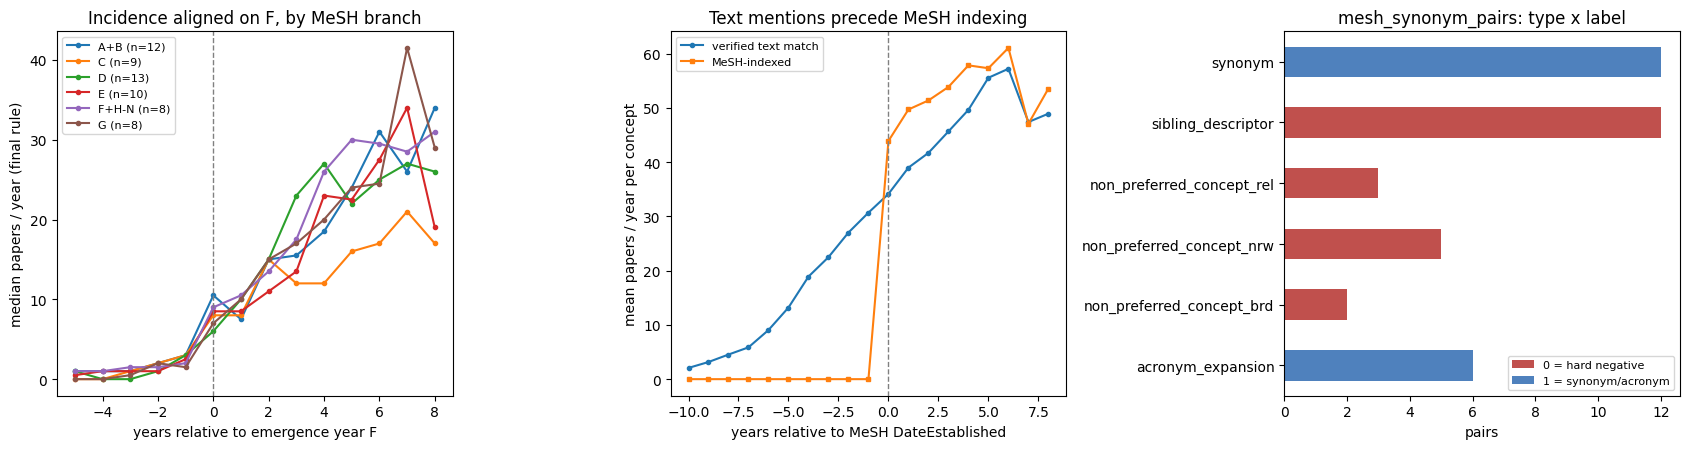

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (1) final-rule yearly counts aligned on emergence year F, median per branch group
ax = axes[0]
rel = np.arange(-5, 9)
for b, g in df.groupby("branch"):
    M = []
    for _, r in g.iterrows():
        idx = r["F"] - 2000 + rel
        M.append([r["final"][k] if 0 <= k < len(years) else np.nan for k in idx])
    ax.plot(rel, np.nanmedian(np.array(M), axis=0), marker="o", ms=3, label=f"{b} (n={len(g)})")
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("years relative to emergence year F"); ax.set_ylabel("median papers / year (final rule)")
ax.set_title("Incidence aligned on F, by MeSH branch"); ax.legend(fontsize=8)

# (2) text-match vs MeSH-indexed counts relative to the year the descriptor was established
#     (mean over concepts that have data at that offset; late descriptors have no years after 2024)
ax = axes[1]
rel2 = np.arange(-10, 9)
T, Mh = [], []
for _, r in df.iterrows():
    idx = r["year_est"] - 2000 + rel2
    T.append([r["text"][k] if 0 <= k < len(years) else np.nan for k in idx])
    Mh.append([r["mesh"][k] if 0 <= k < len(years) else np.nan for k in idx])
ax.plot(rel2, np.nanmean(T, axis=0), marker="o", ms=3, label="verified text match")
ax.plot(rel2, np.nanmean(Mh, axis=0), marker="s", ms=3, label="MeSH-indexed")
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("years relative to MeSH DateEstablished"); ax.set_ylabel("mean papers / year per concept")
ax.set_title("Text mentions precede MeSH indexing"); ax.legend(fontsize=8)

# (3) synonym-pair label mix
ax = axes[2]
ct = pd.crosstab(pdf["metadata_pair_type"], pdf["output"])
ct.plot(kind="barh", stacked=True, ax=ax, color=["#c0504d", "#4f81bd"])
ax.set_xlabel("pairs"); ax.set_ylabel(""); ax.set_title("mesh_synonym_pairs: type x label")
ax.legend(["0 = hard negative", "1 = synonym/acronym"], fontsize=8)

plt.tight_layout(); plt.show()